In [1]:
# ============================================================
# 0. Kaggle notebook setup notes
# ============================================================

import os
from pathlib import Path

print("/kaggle/input exists:", Path("/kaggle/input").exists())
if Path("/kaggle/input").exists():
    print("Kaggle input datasets:")
    for p in sorted(Path("/kaggle/input").iterdir()):
        print(" -", p)

/kaggle/input exists: True
Kaggle input datasets:
 - /kaggle/input/notebooks


In [2]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import math
import time
import shutil
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import joblib
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))



Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [3]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "BEST-TWITTER-ROBERTA_SEED-ENSEMBLE",
    "model_family": "seed_ensemble_fine_tuned_transformer_roberta",
    "feature_family": "contextual_transformer_sequence_representation",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths
    "processed_dataset_path": None,
    "split_assignments_path": None,
    "dataset_manifest_path": None,

    # Transformer checkpoint
    "pretrained_model_name_or_path": "cardiffnlp/twitter-roberta-base-hate-latest",

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    # Mirrors the current Kaggle-style notebooks in the repo.
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Candidate-selection grid, validation only.
    # This is intentionally small because transformer fine-tuning is expensive.
    "ablation_grid": {
        "learning_rate": [1e-5, 2e-5],
        "num_epochs": [3],
        "batch_size": [8],
        "max_length": [192],
        "weight_decay": [0.01],
        "loss_type": ["weighted_ce", "weighted_focal"],
    },

    # Final seed ensemble.
    # For the strongest/stablest final run, keep three seeds.
    "ensemble_seeds": [30, 31, 32],

    # Transformer training settings
    "transformer_training": {
        "gradient_accumulation_steps": 2,
        "warmup_ratio": 0.10,
        "max_grad_norm": 1.0,
        "drop_last": False,
        "num_workers": 2,
        "use_amp_if_cuda": True,
        "early_stopping_patience_epochs": 1,
        "metric_for_best_epoch": "positive_f1",
        "focal_gamma": 2.0,
        "label_smoothing": 0.02,
    },

    # Probability / thresholding
    "threshold_selection": {
        "metric": "positive_f1",
        "threshold_grid": [round(x, 3) for x in np.linspace(0.05, 0.95, 181)],
    },

    # XAI / interpretability
    "explainability": {
        "run_token_attributions_for_review_queue": True,
        "top_n_local_tokens": 15,
        "max_review_examples_with_attributions": 20,
        "max_text_chars_for_display": 400,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 30,
        "near_threshold_margin": 0.05,
        "include_text_preview": True,
        "text_preview_chars": 500,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

if CONFIG["overwrite_output_dir"] and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for subdir in [
    OUTPUT_DIR,
    OUTPUT_DIR / "ablation",
    OUTPUT_DIR / "model_artifacts",
    OUTPUT_DIR / "plots",
    OUTPUT_DIR / "interpretability",
    OUTPUT_DIR / "error_analysis",
    OUTPUT_DIR / "training_logs",
]:
    subdir.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Output directory:", OUTPUT_DIR)
save_config_preview = {k: v for k, v in CONFIG.items() if k != "ablation_grid"}
print(json.dumps(save_config_preview, indent=2, default=str))



Run ID: BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426
Output directory: /kaggle/working/experiments/BEST-TWITTER-ROBERTA_SEED-ENSEMBLE
{
  "project_name": "extremism_text_classification",
  "technique_name": "BEST-TWITTER-ROBERTA_SEED-ENSEMBLE",
  "model_family": "seed_ensemble_fine_tuned_transformer_roberta",
  "feature_family": "contextual_transformer_sequence_representation",
  "dataset_version": "extremism_dataset_clean_v1",
  "split_version": "split_v1",
  "random_seed": 30,
  "processed_dataset_path": null,
  "split_assignments_path": null,
  "dataset_manifest_path": null,
  "pretrained_model_name_or_path": "cardiffnlp/twitter-roberta-base-hate-latest",
  "id_col": "row_id",
  "text_col": "text",
  "label_col": "label",
  "split_col": "split",
  "positive_label": 1,
  "output_root": "/kaggle/working/experiments",
  "overwrite_output_dir": true,
  "ensemble_seeds": [
    30,
    31,
    32
  ],
  "transformer_training": {
    "gradient_accumulation_steps": 2,
    "warmup_rati

In [4]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic=True can slow transformer training substantially; benchmark=True is faster on Kaggle GPUs.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def make_json_safe(obj):
    """Convert numpy/torch/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if math.isnan(float(obj)):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj


def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)


def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]


def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {file_name}. Add the file as Kaggle input data or set its path explicitly in CONFIG."
        )
    if len(matches) > 1:
        print(f"Multiple matches found for {file_name}; using shortest path:")
        for m in matches[:10]:
            print(" -", m)
    return matches[0]


def build_param_grid(grid: dict) -> List[dict]:
    keys = list(grid.keys())
    values = [grid[k] for k in keys]
    return [dict(zip(keys, combo)) for combo in product(*values)]


set_global_seed(CONFIG["random_seed"])
save_json(CONFIG, OUTPUT_DIR / "config.json")
print("Seed set to", CONFIG["random_seed"])




Seed set to 30


In [5]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

# Manifest is useful but optional if only the CSVs were added as Kaggle inputs.
try:
    dataset_manifest_path = (
        Path(CONFIG["dataset_manifest_path"])
        if CONFIG["dataset_manifest_path"] is not None
        else find_file_by_name("dataset_manifest.json")
    )
    with open(dataset_manifest_path, "r") as f:
        dataset_manifest = json.load(f)
except Exception as e:
    dataset_manifest_path = None
    dataset_manifest = {"warning": f"dataset_manifest.json not loaded: {e}"}

processed_df = pd.read_csv(processed_dataset_path)
splits_df = pd.read_csv(split_assignments_path)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset manifest path:", dataset_manifest_path)
print("Processed dataset shape:", processed_df.shape)
print("Split assignments shape:", splits_df.shape)

display(processed_df.head())
display(splits_df.head())




Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset manifest path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Processed dataset shape: (2999, 8)
Split assignments shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,validation
3,ex_000003,1,4bedb3fea5ed5fbe,validation
4,ex_000004,1,f1a8b2543327a925,validation


In [6]:
# ============================================================
# 5. Validate and merge fixed splits
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]
positive_label = CONFIG["positive_label"]

required_dataset_cols = {id_col, text_col, label_col}
missing_dataset_cols = required_dataset_cols - set(processed_df.columns)
if missing_dataset_cols:
    raise ValueError(f"processed_dataset.csv is missing columns: {missing_dataset_cols}")

required_split_cols = {id_col, split_col}
missing_split_cols = required_split_cols - set(splits_df.columns)
if missing_split_cols:
    raise ValueError(f"split_assignments.csv is missing columns: {missing_split_cols}")

# Keep split label only once if both files contain a label column.
split_cols_to_use = [id_col, split_col]
if "text_hash" in splits_df.columns:
    split_cols_to_use.append("text_hash")

merged = processed_df.merge(
    splits_df[split_cols_to_use],
    on=id_col,
    how="inner",
    validate="one_to_one",
    suffixes=("", "_splitfile"),
)

if len(merged) != len(processed_df):
    raise ValueError(f"Merge lost rows: processed={len(processed_df)}, merged={len(merged)}")

merged[text_col] = merged[text_col].fillna("").astype(str)
merged[label_col] = merged[label_col].astype(int)
merged[split_col] = merged[split_col].astype(str).str.lower().str.strip()

if "text_hash" not in merged.columns:
    merged["text_hash"] = merged[text_col].map(sha256_text)

valid_splits = {"train", "validation", "test"}
unknown_splits = sorted(set(merged[split_col]) - valid_splits)
if unknown_splits:
    raise ValueError(f"Unexpected split values: {unknown_splits}")

train_df = merged[merged[split_col] == "train"].copy().reset_index(drop=True)
val_df = merged[merged[split_col] == "validation"].copy().reset_index(drop=True)
test_df = merged[merged[split_col] == "test"].copy().reset_index(drop=True)

print("Split sizes:")
for name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name}: {len(split_df)}")

display(
    merged.groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
    .assign(rate_within_split=lambda d: d["count"] / d.groupby(split_col)["count"].transform("sum"))
)

save_json({
    "processed_dataset_path": str(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "dataset_manifest_path": str(dataset_manifest_path) if dataset_manifest_path else None,
    "n_rows": len(merged),
    "split_counts": merged[split_col].value_counts().to_dict(),
    "label_counts": merged[label_col].value_counts().to_dict(),
    "dataset_manifest": dataset_manifest,
}, OUTPUT_DIR / "data_audit.json")



Split sizes:
train: 2099
validation: 450
test: 450


,split,label,count,rate_within_split
0,test,0,280,0.622222
1,test,1,170,0.377778
2,train,0,1309,0.623630
3,train,1,790,0.376370
4,validation,0,281,0.624444
5,validation,1,169,0.375556


In [7]:
# ============================================================
# 6. Metric, threshold, and plotting helpers
# ============================================================

def evaluate_binary_predictions(y_true, y_prob, threshold: float) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "positive_precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "positive_recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "positive_f1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
    }
    return {k: make_json_safe(v) for k, v in metrics.items()}


def select_threshold(y_true, y_prob, metric_name: str, thresholds: List[float]) -> Tuple[float, pd.DataFrame]:
    rows = []
    for threshold in thresholds:
        row = evaluate_binary_predictions(y_true, y_prob, threshold)
        rows.append(row)
    sweep = pd.DataFrame(rows)
    if metric_name not in sweep.columns:
        raise ValueError(f"Metric {metric_name} not found in threshold sweep columns")
    best_row = sweep.sort_values([metric_name, "positive_recall", "positive_precision"], ascending=False).iloc[0]
    return float(best_row["threshold"]), sweep


def save_standard_reports(y_true, y_prob, threshold: float, split_name: str, out_dir: Path) -> Dict[str, float]:
    metrics = evaluate_binary_predictions(y_true, y_prob, threshold)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    save_json(metrics, out_dir / f"metrics_{split_name}.json")
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["NON_EXTREMIST", "EXTREMIST"],
        output_dict=True,
        zero_division=0,
    )
    save_json(report, out_dir / f"classification_report_{split_name}.json")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["true_NON_EXTREMIST", "true_EXTREMIST"], columns=["pred_NON_EXTREMIST", "pred_EXTREMIST"])
    cm_df.to_csv(out_dir / f"confusion_matrix_{split_name}.csv")
    return metrics


def plot_curves(y_true, y_prob, threshold: float, split_name: str, out_dir: Path) -> None:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {split_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_dir / f"roc_curve_{split_name}.png", dpi=200)
    plt.show()

    # Precision-recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_true, y_prob):.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {split_name}")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(out_dir / f"precision_recall_curve_{split_name}.png", dpi=200)
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix — {split_name}")
    plt.xticks([0, 1], ["Pred Non", "Pred Ext"])
    plt.yticks([0, 1], ["True Non", "True Ext"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(out_dir / f"confusion_matrix_{split_name}.png", dpi=200)
    plt.show()

    # Calibration curve
    try:
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
        plt.figure(figsize=(6, 5))
        plt.plot(mean_pred, frac_pos, marker="o", label="Model")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction positives")
        plt.title(f"Calibration Curve — {split_name}")
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.savefig(out_dir / f"calibration_curve_{split_name}.png", dpi=200)
        plt.show()
    except Exception as e:
        print("Calibration plot skipped:", e)



In [8]:
# ============================================================
# 7. Transformer dataset and loss functions
# ============================================================

class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length: int):
        self.labels = torch.tensor(np.asarray(labels).astype(int), dtype=torch.long)
        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal


def get_class_weights(y_train, device):
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).astype(int))
    return torch.tensor(weights, dtype=torch.float32, device=device)


def build_loss_fn(loss_type: str, class_weights: torch.Tensor, device):
    if loss_type == "weighted_ce":
        return nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=CONFIG["transformer_training"]["label_smoothing"],
        )
    if loss_type == "weighted_focal":
        return FocalLoss(
            weight=class_weights,
            gamma=CONFIG["transformer_training"]["focal_gamma"],
        )
    raise ValueError(f"Unknown loss_type: {loss_type}")



In [9]:
# ============================================================
# 8. Training and inference functions
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def make_loaders(tokenizer, max_length: int, batch_size: int):
    train_dataset = TextClassificationDataset(train_df[text_col].tolist(), train_df[label_col].tolist(), tokenizer, max_length)
    val_dataset = TextClassificationDataset(val_df[text_col].tolist(), val_df[label_col].tolist(), tokenizer, max_length)
    test_dataset = TextClassificationDataset(test_df[text_col].tolist(), test_df[label_col].tolist(), tokenizer, max_length)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CONFIG["transformer_training"]["num_workers"],
        drop_last=CONFIG["transformer_training"]["drop_last"],
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size * 2, shuffle=False, num_workers=CONFIG["transformer_training"]["num_workers"])
    test_loader = DataLoader(test_dataset, batch_size=batch_size * 2, shuffle=False, num_workers=CONFIG["transformer_training"]["num_workers"])
    return train_loader, val_loader, test_loader


@torch.no_grad()
def predict_probabilities(model, loader) -> np.ndarray:
    model.eval()
    probs = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        outputs = model(**batch)
        batch_probs = torch.softmax(outputs.logits, dim=-1)[:, positive_label]
        probs.append(batch_probs.detach().cpu().numpy())
    return np.concatenate(probs)


def train_transformer_member(
    model_config: Dict,
    seed: int,
    member_name: str,
    save_member: bool = True,
    return_test_probs: bool = False,
):
    set_global_seed(seed)
    member_start = time.time()

    tokenizer = AutoTokenizer.from_pretrained(CONFIG["pretrained_model_name_or_path"], use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["pretrained_model_name_or_path"],
        num_labels=2,
        ignore_mismatched_sizes=True,
    )
    model.to(device)

    train_loader, val_loader, test_loader = make_loaders(
        tokenizer=tokenizer,
        max_length=int(model_config["max_length"]),
        batch_size=int(model_config["batch_size"]),
    )

    class_weights = get_class_weights(train_df[label_col].values, device=device)
    loss_fn = build_loss_fn(model_config["loss_type"], class_weights, device=device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(model_config["learning_rate"]),
        weight_decay=float(model_config["weight_decay"]),
    )

    total_update_steps = math.ceil(len(train_loader) / CONFIG["transformer_training"]["gradient_accumulation_steps"]) * int(model_config["num_epochs"])
    warmup_steps = int(total_update_steps * CONFIG["transformer_training"]["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda" and CONFIG["transformer_training"]["use_amp_if_cuda"]))

    best_state_dict = None
    best_epoch_metrics = None
    best_epoch = None
    best_threshold = None
    best_score = -np.inf
    patience_left = CONFIG["transformer_training"]["early_stopping_patience_epochs"]
    epoch_logs = []

    for epoch in range(1, int(model_config["num_epochs"]) + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        running_loss = 0.0
        n_batches = 0

        for step, batch in enumerate(train_loader, start=1):
            labels = batch["labels"].to(device)
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda" and CONFIG["transformer_training"]["use_amp_if_cuda"])):
                outputs = model(**inputs)
                loss = loss_fn(outputs.logits, labels)
                loss = loss / CONFIG["transformer_training"]["gradient_accumulation_steps"]

            scaler.scale(loss).backward()
            running_loss += float(loss.detach().cpu()) * CONFIG["transformer_training"]["gradient_accumulation_steps"]
            n_batches += 1

            if step % CONFIG["transformer_training"]["gradient_accumulation_steps"] == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["transformer_training"]["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        val_probs = predict_probabilities(model, val_loader)
        epoch_threshold, epoch_sweep = select_threshold(
            val_df[label_col].values,
            val_probs,
            CONFIG["threshold_selection"]["metric"],
            CONFIG["threshold_selection"]["threshold_grid"],
        )
        epoch_metrics = evaluate_binary_predictions(val_df[label_col].values, val_probs, epoch_threshold)
        epoch_metrics.update({
            "epoch": epoch,
            "train_loss": running_loss / max(n_batches, 1),
            "selected_threshold": epoch_threshold,
        })
        epoch_logs.append(epoch_metrics)

        score = float(epoch_metrics[CONFIG["transformer_training"]["metric_for_best_epoch"]])
        print(
            f"{member_name} | epoch {epoch} | loss={epoch_metrics['train_loss']:.4f} | "
            f"val_f1={epoch_metrics['positive_f1']:.4f} | val_precision={epoch_metrics['positive_precision']:.4f} | "
            f"val_recall={epoch_metrics['positive_recall']:.4f} | threshold={epoch_threshold:.3f}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_epoch_metrics = epoch_metrics
            best_threshold = epoch_threshold
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = CONFIG["transformer_training"]["early_stopping_patience_epochs"]
        else:
            patience_left -= 1
            if patience_left < 0:
                print(f"{member_name} | early stopping after epoch {epoch}")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    val_probs = predict_probabilities(model, val_loader)
    result = {
        "member_name": member_name,
        "seed": seed,
        "model_config": model_config,
        "best_epoch": best_epoch,
        "best_epoch_metrics": best_epoch_metrics,
        "best_epoch_threshold": best_threshold,
        "validation_probs": val_probs,
        "epoch_logs": epoch_logs,
        "runtime_seconds": time.time() - member_start,
    }

    if return_test_probs:
        result["test_probs"] = predict_probabilities(model, test_loader)

    if save_member:
        member_dir = OUTPUT_DIR / "model_artifacts" / member_name
        member_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(member_dir)
        tokenizer.save_pretrained(member_dir)
        save_json({k: v for k, v in result.items() if k not in {"validation_probs", "test_probs"}}, member_dir / "member_training_summary.json")
        pd.DataFrame(epoch_logs).to_csv(member_dir / "epoch_logs.csv", index=False)

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return result



Using device: cuda


In [10]:
# ============================================================
# 9. Validation-only candidate selection
# ============================================================

candidate_configs = build_param_grid(CONFIG["ablation_grid"])
print(f"Candidate configurations: {len(candidate_configs)}")

ablation_rows = []
ablation_results = []

for i, candidate_config in enumerate(candidate_configs, start=1):
    member_name = f"candidate_{i:02d}"
    print("\n" + "=" * 80)
    print(f"Training {member_name}/{len(candidate_configs)}")
    print(candidate_config)

    result = train_transformer_member(
        model_config=candidate_config,
        seed=CONFIG["random_seed"],
        member_name=member_name,
        save_member=False,
        return_test_probs=False,
    )

    # Select candidate threshold on validation only.
    selected_threshold, threshold_sweep = select_threshold(
        val_df[label_col].values,
        result["validation_probs"],
        CONFIG["threshold_selection"]["metric"],
        CONFIG["threshold_selection"]["threshold_grid"],
    )
    val_metrics = evaluate_binary_predictions(val_df[label_col].values, result["validation_probs"], selected_threshold)

    row = {
        "candidate_id": i,
        "member_name": member_name,
        "selected_threshold": selected_threshold,
        "runtime_seconds": result["runtime_seconds"],
        **candidate_config,
        **{f"validation_{k}": v for k, v in val_metrics.items()},
    }
    ablation_rows.append(row)
    ablation_results.append({
        "candidate_config": candidate_config,
        "selected_threshold": selected_threshold,
        "validation_metrics": val_metrics,
        "validation_probs": result["validation_probs"],
        "epoch_logs": result["epoch_logs"],
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df.sort_values(
    [f"validation_{CONFIG['threshold_selection']['metric']}", "validation_positive_recall", "validation_positive_precision"],
    ascending=False,
).reset_index(drop=True)

ablation_df.to_csv(OUTPUT_DIR / "ablation_results.csv", index=False)
ablation_df.to_csv(OUTPUT_DIR / "ablation" / "ablation_results.csv", index=False)
display(ablation_df)

best_candidate_id = int(ablation_df.iloc[0]["candidate_id"])
best_candidate = ablation_results[best_candidate_id - 1]
best_config = best_candidate["candidate_config"]

print("Best candidate ID:", best_candidate_id)
print("Best config:", best_config)
print("Best validation metrics:")
print(json.dumps(best_candidate["validation_metrics"], indent=2))



Candidate configurations: 4

Training candidate_01/4
{'learning_rate': 1e-05, 'num_epochs': 3, 'batch_size': 8, 'max_length': 192, 'weight_decay': 0.01, 'loss_type': 'weighted_ce'}


config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


candidate_04 | epoch 1 | loss=0.3041 | val_f1=0.7978 | val_precision=0.7327 | val_recall=0.8757 | threshold=0.475
candidate_04 | epoch 2 | loss=0.0752 | val_f1=0.8214 | val_precision=0.8263 | val_recall=0.8166 | threshold=0.640
candidate_04 | epoch 3 | loss=0.0417 | val_f1=0.8129 | val_precision=0.8035 | val_recall=0.8225 | threshold=0.635


,candidate_id,member_name,selected_threshold,runtime_seconds,learning_rate,num_epochs,batch_size,max_length,weight_decay,loss_type,validation_threshold,validation_accuracy,validation_balanced_accuracy,validation_positive_precision,validation_positive_recall,validation_positive_f1,validation_roc_auc,validation_pr_auc,validation_brier_score,validation_tn,validation_fp,validation_fn,validation_tp,validation_fpr,validation_fnr
0,4,candidate_04,0.640,106.793242,0.00002,3,8,192,0.01,weighted_focal,0.640,0.866667,0.856683,0.826347,0.816568,0.821429,0.932616,0.901998,0.117335,252,29,31,138,0.103203,0.183432
1,1,candidate_01,0.305,125.157858,0.00001,3,8,192,0.01,weighted_ce,0.305,0.855556,0.860757,0.768041,0.881657,0.820937,0.927078,0.895566,0.118316,236,45,20,149,0.160142,0.118343
2,3,candidate_03,0.775,107.593925,0.00002,3,8,192,0.01,weighted_ce,0.775,0.868889,0.850207,0.861842,0.775148,0.816199,0.929668,0.901180,0.116293,260,21,38,131,0.074733,0.224852
3,2,candidate_02,0.530,106.874769,0.00001,3,8,192,0.01,weighted_focal,0.530,0.853333,0.855440,0.772487,0.863905,0.815642,0.929163,0.898089,0.112519,238,43,23,146,0.153025,0.136095


Best candidate ID: 4
Best config: {'learning_rate': 2e-05, 'num_epochs': 3, 'batch_size': 8, 'max_length': 192, 'weight_decay': 0.01, 'loss_type': 'weighted_focal'}
Best validation metrics:
{
  "threshold": 0.64,
  "accuracy": 0.8666666666666667,
  "balanced_accuracy": 0.8566826001810945,
  "positive_precision": 0.8263473053892215,
  "positive_recall": 0.8165680473372781,
  "positive_f1": 0.8214285714285714,
  "roc_auc": 0.9326159742256102,
  "pr_auc": 0.9019982738135325,
  "brier_score": 0.11733490360400778,
  "tn": 252,
  "fp": 29,
  "fn": 31,
  "tp": 138,
  "fpr": 0.10320284697508897,
  "fnr": 0.1834319526627219
}


In [11]:
# ============================================================
# 10. Train final seed ensemble using the selected config
# ============================================================

ensemble_val_probs = []
ensemble_test_probs = []
ensemble_member_summaries = []

for member_idx, seed in enumerate(CONFIG["ensemble_seeds"], start=1):
    member_name = f"ensemble_member_{member_idx:02d}_seed_{seed}"
    print("\n" + "=" * 80)
    print(f"Training final ensemble member: {member_name}")

    result = train_transformer_member(
        model_config=best_config,
        seed=seed,
        member_name=member_name,
        save_member=True,
        return_test_probs=True,
    )
    ensemble_val_probs.append(result["validation_probs"])
    ensemble_test_probs.append(result["test_probs"])
    ensemble_member_summaries.append({
        "member_name": member_name,
        "seed": seed,
        "best_epoch": result["best_epoch"],
        "best_epoch_metrics": result["best_epoch_metrics"],
        "runtime_seconds": result["runtime_seconds"],
    })

val_prob_ensemble = np.mean(np.vstack(ensemble_val_probs), axis=0)
test_prob_ensemble = np.mean(np.vstack(ensemble_test_probs), axis=0)

# Also save member-level probability spread for uncertainty analysis.
val_prob_std = np.std(np.vstack(ensemble_val_probs), axis=0)
test_prob_std = np.std(np.vstack(ensemble_test_probs), axis=0)

final_threshold, final_threshold_sweep = select_threshold(
    val_df[label_col].values,
    val_prob_ensemble,
    CONFIG["threshold_selection"]["metric"],
    CONFIG["threshold_selection"]["threshold_grid"],
)

final_threshold_sweep.to_csv(OUTPUT_DIR / "threshold_sweep_validation.csv", index=False)

final_best_config = {
    "run_id": RUN_ID,
    "technique_name": TECHNIQUE_NAME,
    "pretrained_model_name_or_path": CONFIG["pretrained_model_name_or_path"],
    "best_single_seed_candidate_id": best_candidate_id,
    "best_model_config": best_config,
    "ensemble_seeds": CONFIG["ensemble_seeds"],
    "selected_threshold": final_threshold,
    "threshold_selection_split": "validation",
    "threshold_selection_metric": CONFIG["threshold_selection"]["metric"],
    "ensemble_member_summaries": ensemble_member_summaries,
}

save_json(final_best_config, OUTPUT_DIR / "best_config.json")
save_json(ensemble_member_summaries, OUTPUT_DIR / "model_artifacts" / "ensemble_member_summaries.json")

print("Final validation-selected threshold:", final_threshold)
print(json.dumps(final_best_config, indent=2, default=str))




Training final ensemble member: ensemble_member_01_seed_30


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ensemble_member_01_seed_30 | epoch 1 | loss=0.3041 | val_f1=0.7978 | val_precision=0.7327 | val_recall=0.8757 | threshold=0.475
ensemble_member_01_seed_30 | epoch 2 | loss=0.0752 | val_f1=0.8214 | val_precision=0.8263 | val_recall=0.8166 | threshold=0.640
ensemble_member_01_seed_30 | epoch 3 | loss=0.0417 | val_f1=0.8129 | val_precision=0.8035 | val_recall=0.8225 | threshold=0.635


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ensemble_member_03_seed_32 | epoch 1 | loss=0.2983 | val_f1=0.8152 | val_precision=0.8081 | val_recall=0.8225 | threshold=0.495
ensemble_member_03_seed_32 | epoch 2 | loss=0.0735 | val_f1=0.8136 | val_precision=0.7784 | val_recall=0.8521 | threshold=0.525
ensemble_member_03_seed_32 | epoch 3 | loss=0.0411 | val_f1=0.8201 | val_precision=0.8176 | val_recall=0.8225 | threshold=0.715


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final validation-selected threshold: 0.585
{
  "run_id": "BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426",
  "technique_name": "BEST-TWITTER-ROBERTA_SEED-ENSEMBLE",
  "pretrained_model_name_or_path": "cardiffnlp/twitter-roberta-base-hate-latest",
  "best_single_seed_candidate_id": 4,
  "best_model_config": {
    "learning_rate": 2e-05,
    "num_epochs": 3,
    "batch_size": 8,
    "max_length": 192,
    "weight_decay": 0.01,
    "loss_type": "weighted_focal"
  },
  "ensemble_seeds": [
    30,
    31,
    32
  ],
  "selected_threshold": 0.585,
  "threshold_selection_split": "validation",
  "threshold_selection_metric": "positive_f1",
  "ensemble_member_summaries": [
    {
      "member_name": "ensemble_member_01_seed_30",
      "seed": 30,
      "best_epoch": 2,
      "best_epoch_metrics": {
        "threshold": 0.64,
        "accuracy": 0.8666666666666667,
        "balanced_accuracy": 0.8566826001810945,
        "positive_precision": 0.8263473053892215,
        "positive_recall": 0

In [12]:
# ============================================================
# 11. Final validation and held-out test evaluation
# ============================================================

val_metrics = save_standard_reports(val_df[label_col].values, val_prob_ensemble, final_threshold, "validation", OUTPUT_DIR)
test_metrics = save_standard_reports(test_df[label_col].values, test_prob_ensemble, final_threshold, "test", OUTPUT_DIR)

print("Validation metrics:")
print(json.dumps(val_metrics, indent=2))
print("\nHeld-out test metrics:")
print(json.dumps(test_metrics, indent=2))

# Save summary for easy comparison with other model folders.
summary_row = {
    "technique": TECHNIQUE_NAME,
    "threshold": final_threshold,
    **{f"validation_{k}": v for k, v in val_metrics.items()},
    **{f"test_{k}": v for k, v in test_metrics.items()},
}
pd.DataFrame([summary_row]).to_csv(OUTPUT_DIR / "summary_row.csv", index=False)



Validation metrics:
{
  "threshold": 0.585,
  "accuracy": 0.8577777777777778,
  "balanced_accuracy": 0.8566404851649856,
  "positive_precision": 0.7868852459016393,
  "positive_recall": 0.8520710059171598,
  "positive_f1": 0.8181818181818182,
  "roc_auc": 0.9359009454821117,
  "pr_auc": 0.9056915485586737,
  "brier_score": 0.11022816729012741,
  "tn": 242,
  "fp": 39,
  "fn": 25,
  "tp": 144,
  "fpr": 0.1387900355871886,
  "fnr": 0.14792899408284024
}

Held-out test metrics:
{
  "threshold": 0.585,
  "accuracy": 0.8777777777777778,
  "balanced_accuracy": 0.8740546218487395,
  "positive_precision": 0.8248587570621468,
  "positive_recall": 0.8588235294117647,
  "positive_f1": 0.8414985590778098,
  "roc_auc": 0.9552521008403361,
  "pr_auc": 0.9374377511844288,
  "brier_score": 0.09299156719022636,
  "tn": 249,
  "fp": 31,
  "fn": 24,
  "tp": 146,
  "fpr": 0.11071428571428571,
  "fnr": 0.1411764705882353
}


In [13]:
# ============================================================
# 12. Save predictions for validation and test
# ============================================================

def make_prediction_frame(split_df: pd.DataFrame, y_prob: np.ndarray, y_prob_std: np.ndarray, threshold: float) -> pd.DataFrame:
    out = split_df[[id_col, text_col, label_col, split_col, "text_hash"]].copy()
    out = out.rename(columns={label_col: "y_true"})
    out["run_id"] = RUN_ID
    out["technique"] = TECHNIQUE_NAME
    out["y_prob"] = y_prob
    out["y_score"] = y_prob
    out["y_prob_ensemble_std"] = y_prob_std
    out["threshold"] = threshold
    out["y_pred"] = (out["y_prob"] >= threshold).astype(int)
    out["correct"] = out["y_true"].astype(int) == out["y_pred"].astype(int)
    out["abs_distance_to_threshold"] = (out["y_prob"] - threshold).abs()
    return out

val_pred_df = make_prediction_frame(val_df, val_prob_ensemble, val_prob_std, final_threshold)
test_pred_df = make_prediction_frame(test_df, test_prob_ensemble, test_prob_std, final_threshold)

val_pred_df.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_pred_df.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

display(test_pred_df.head())



,row_id,text,y_true,split,text_hash,run_id,technique,y_prob,y_score,y_prob_ensemble_std,threshold,y_pred,correct,abs_distance_to_threshold
0,ex_000000,sixth forms should burn to the ground,1,test,e0cc81a4d5f0f2b3,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.958965,0.958965,0.021852,0.585,1,True,0.373965
1,ex_000012,ill kill your family so they do not exist anymore,1,test,1c94926b81fc81a8,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.974287,0.974287,0.008734,0.585,1,True,0.389287
2,ex_000021,she should be banned for life for defending muslims against terrorism,1,test,aaaf481f25917405,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.460232,0.460232,0.068226,0.585,0,False,0.124768
3,ex_000023,i will kill this afro american so he does not bother us anymore,1,test,4fb27b01defd61d6,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.967981,0.967981,0.013341,0.585,1,True,0.382981
4,ex_000034,i hate wearing my hijab because people think i am a terrorist,0,test,024bc26847a63b8a,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.478038,0.478038,0.028597,0.585,0,True,0.106962


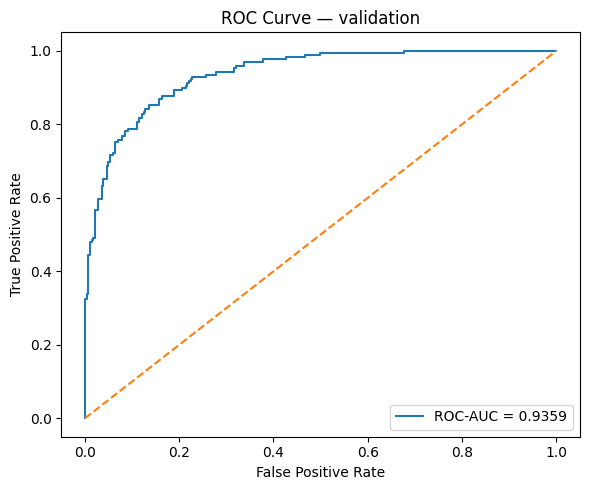

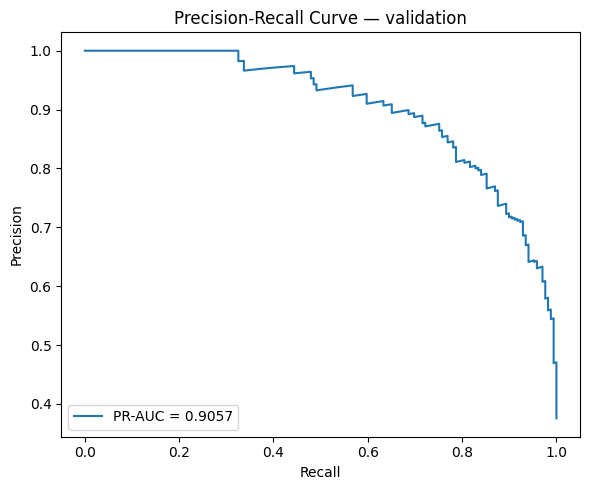

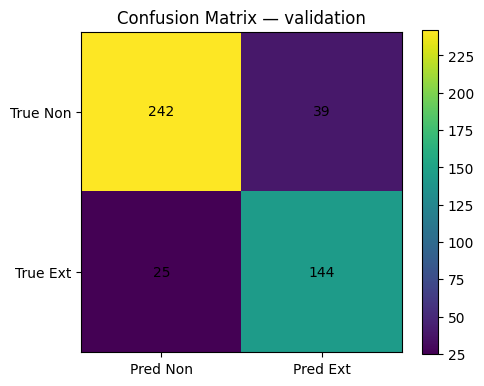

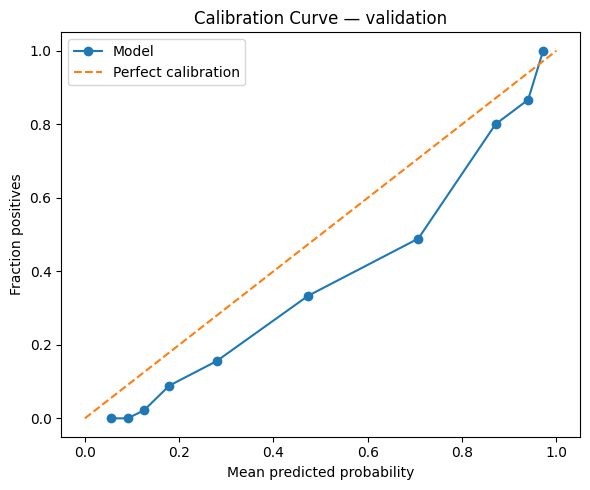

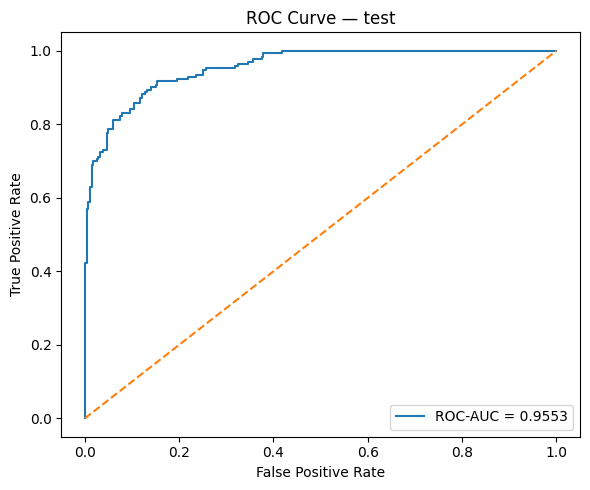

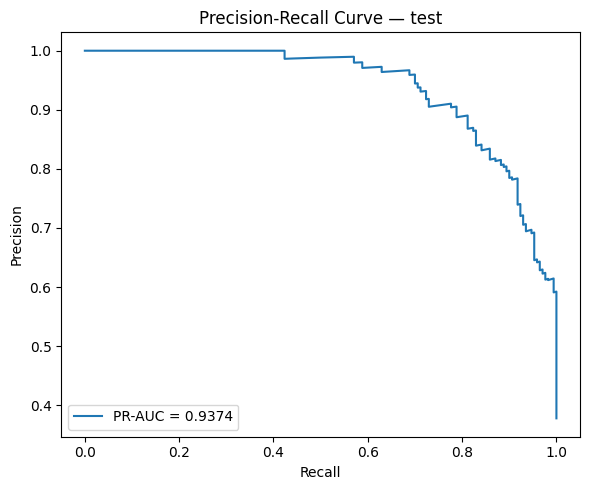

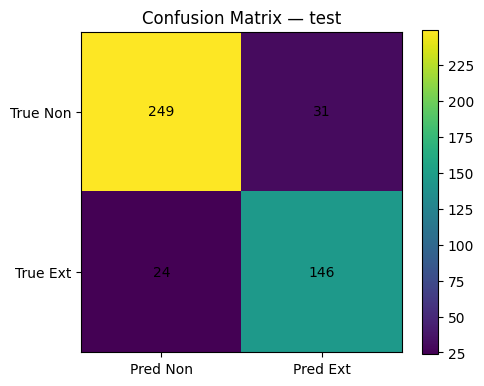

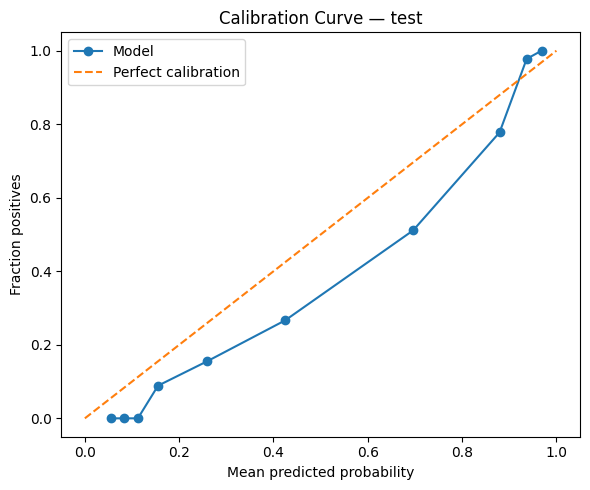

In [14]:
# ============================================================
# 13. Plots
# ============================================================

plot_curves(val_df[label_col].values, val_prob_ensemble, final_threshold, "validation", OUTPUT_DIR / "plots")
plot_curves(test_df[label_col].values, test_prob_ensemble, final_threshold, "test", OUTPUT_DIR / "plots")



In [15]:
# ============================================================
# 14. Error analysis helpers
# ============================================================

def label_error_type(row) -> str:
    y_true = int(row["y_true"])
    y_pred = int(row["y_pred"])
    if y_true == 1 and y_pred == 1:
        return "true_positive"
    if y_true == 0 and y_pred == 0:
        return "true_negative"
    if y_true == 0 and y_pred == 1:
        return "false_positive"
    if y_true == 1 and y_pred == 0:
        return "false_negative"
    return "unknown"


def confidence_bucket(row) -> str:
    p = float(row["y_prob"])
    threshold = float(row["threshold"])
    distance = abs(p - threshold)
    if distance <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if p >= 0.85 or p <= 0.15:
        return "high_confidence"
    return "moderate_confidence"


def build_error_analysis_frame(pred_df: pd.DataFrame) -> pd.DataFrame:
    out = pred_df.copy()
    out["error_type"] = out.apply(label_error_type, axis=1)
    out["confidence_bucket"] = out.apply(confidence_bucket, axis=1)
    out["manual_error_category"] = ""
    out["manual_notes"] = ""
    out["top_positive_tokens_json"] = ""
    out["top_negative_tokens_json"] = ""
    if CONFIG["error_analysis"]["include_text_preview"]:
        n = CONFIG["error_analysis"]["text_preview_chars"]
        out["text_preview"] = out[text_col].astype(str).str.slice(0, n)
    return out


def build_manual_review_queue(error_df: pd.DataFrame) -> pd.DataFrame:
    k = CONFIG["error_analysis"]["examples_per_bucket"]
    frames = []

    fp = error_df[error_df["error_type"] == "false_positive"].copy()
    fn = error_df[error_df["error_type"] == "false_negative"].copy()
    near = error_df[error_df["confidence_bucket"] == "near_threshold"].copy()
    uncertain_ensemble = error_df.sort_values("y_prob_ensemble_std", ascending=False).head(k).copy()

    if len(fp):
        a = fp.sort_values("y_prob", ascending=False).head(k).copy()
        a["review_bucket"] = "highest_confidence_false_positive"
        frames.append(a)
    if len(fn):
        a = fn.sort_values("y_prob", ascending=True).head(k).copy()
        a["review_bucket"] = "highest_confidence_false_negative"
        frames.append(a)
    if len(near):
        a = near.sort_values("abs_distance_to_threshold", ascending=True).head(k).copy()
        a["review_bucket"] = "near_threshold"
        frames.append(a)
    if len(uncertain_ensemble):
        a = uncertain_ensemble.copy()
        a["review_bucket"] = "highest_ensemble_disagreement"
        frames.append(a)

    if not frames:
        return error_df.head(0).copy()

    queue = pd.concat(frames, axis=0, ignore_index=True)
    queue = queue.drop_duplicates(subset=[id_col], keep="first")
    queue = queue.sort_values(["correct", "review_bucket", "abs_distance_to_threshold"], ascending=[True, True, True])
    return queue.reset_index(drop=True)



In [16]:
# ============================================================
# 15. Build and save error-analysis artifacts
# ============================================================

error_analysis_test = build_error_analysis_frame(test_pred_df)
manual_review_queue = build_manual_review_queue(error_analysis_test)

error_summary = (
    error_analysis_test
    .groupby(["error_type", "confidence_bucket"])
    .size()
    .reset_index(name="count")
    .sort_values(["error_type", "confidence_bucket"])
)

error_analysis_test.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)
manual_review_queue.to_csv(OUTPUT_DIR / "error_analysis" / "manual_review_queue_test.csv", index=False)
error_summary.to_csv(OUTPUT_DIR / "error_analysis" / "error_summary.csv", index=False)

print("Error summary:")
display(error_summary)

print("Manual review queue:")
display(manual_review_queue.head(20))



Error summary:


,error_type,confidence_bucket,count
0,false_negative,moderate_confidence,21
1,false_negative,near_threshold,3
2,false_positive,high_confidence,8
3,false_positive,moderate_confidence,20
4,false_positive,near_threshold,3
5,true_negative,high_confidence,153
6,true_negative,moderate_confidence,93
7,true_negative,near_threshold,3
8,true_positive,high_confidence,120
9,true_positive,moderate_confidence,23


Manual review queue:


,row_id,text,y_true,split,text_hash,run_id,technique,y_prob,y_score,y_prob_ensemble_std,threshold,y_pred,correct,abs_distance_to_threshold,error_type,confidence_bucket,manual_error_category,manual_notes,top_positive_tokens_json,top_negative_tokens_json,text_preview,review_bucket
0,ex_001692,muzz bs are scum,1,test,166a4db91a53bec3,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.551494,0.551494,0.236916,0.585,0,False,0.033506,false_negative,near_threshold,,,,,muzz bs are scum,highest_confidence_false_negative
1,ex_002149,bitch on the left wont be smiling let them in hawaii it will be rape island,1,test,61a2dddf29610dff,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.550541,0.550541,0.181837,0.585,0,False,0.034459,false_negative,near_threshold,,,,,bitch on the left wont be smiling let them in hawaii it will be rape island,highest_confidence_false_negative
2,ex_001830,you are an ugly monkey go back to where you belong,1,test,2fcd8683f045f9cd,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.538149,0.538149,0.213094,0.585,0,False,0.046851,false_negative,near_threshold,,,,,you are an ugly monkey go back to where you belong,highest_confidence_false_negative
3,ex_000442,leader and i use that word entirely wrongly claims muslims should not adapt to our where are you of life whatever must yield and concede to theirs since trope has legalized bes...,1,test,b9fed00b3cc7dee2,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.525673,0.525673,0.090892,0.585,0,False,0.059327,false_negative,moderate_confidence,,,,,leader and i use that word entirely wrongly claims muslims should not adapt to our where are you of life whatever must yield and concede to theirs since trope has legalized bes...,highest_confidence_false_negative
4,ex_002640,get a bill to hang these rapist hatemongers murderers almighty bless you,1,test,b4f7c01f02ca1723,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.491033,0.491033,0.096260,0.585,0,False,0.093967,false_negative,moderate_confidence,,,,,get a bill to hang these rapist hatemongers murderers almighty bless you,highest_confidence_false_negative
5,ex_000528,how do you make a plumber cry you kill his family,1,test,f41e80019b45c01c,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.484806,0.484806,0.043888,0.585,0,False,0.100194,false_negative,moderate_confidence,,,,,how do you make a plumber cry you kill his family,highest_confidence_false_negative
6,ex_000021,she should be banned for life for defending muslims against terrorism,1,test,aaaf481f25917405,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.460232,0.460232,0.068226,0.585,0,False,0.124768,false_negative,moderate_confidence,,,,,she should be banned for life for defending muslims against terrorism,highest_confidence_false_negative
7,ex_000291,i love the idea of blaming all terrorist attacks on muslims,1,test,f2e57426ce635a73,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.446303,0.446303,0.151888,0.585,0,False,0.138697,false_negative,moderate_confidence,,,,,i love the idea of blaming all terrorist attacks on muslims,highest_confidence_false_negative
8,ex_000090,all sports coverage like all msm is for propaganda purposes only what is being promoted right now on a us world cup pre show a story that luka mondrian the croatian soccer star...,1,test,89e0211bc95dfa9b,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.439797,0.439797,0.059860,0.585,0,False,0.145203,false_negative,moderate_confidence,,,,,all sports coverage like all msm is for propaganda purposes only what is being promoted right now on a us world cup pre show a story that luka mondrian the croatian soccer star...,highest_confidence_false_negative
9,ex_000434,q ho

In [17]:
# ============================================================
# 16. Optional local token attributions for the manual review queue
# ============================================================

# This uses gradient × input embedding from the first ensemble member as a lightweight local explanation.
# It is not a full SHAP explanation. Treat it as a model-inspection artifact, not proof of causal reasoning.

def load_first_ensemble_member():
    first_seed = CONFIG["ensemble_seeds"][0]
    member_dir = OUTPUT_DIR / "model_artifacts" / f"ensemble_member_01_seed_{first_seed}"
    tokenizer = AutoTokenizer.from_pretrained(member_dir, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(member_dir)
    model.to(device)
    model.eval()
    return tokenizer, model


def token_attributions_for_text(text: str, tokenizer, model, max_length: int, top_n: int = 15):
    encoded = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    input_ids = encoded["input_ids"]
    attention_mask = encoded.get("attention_mask", None)

    embeddings_layer = model.get_input_embeddings()
    input_embeds = embeddings_layer(input_ids)
    input_embeds.retain_grad()

    outputs = model(inputs_embeds=input_embeds, attention_mask=attention_mask)
    positive_logit = outputs.logits[0, positive_label]
    model.zero_grad(set_to_none=True)
    positive_logit.backward()

    grads = input_embeds.grad.detach()[0]
    embeds = input_embeds.detach()[0]
    scores = (grads * embeds).sum(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].detach().cpu().tolist())

    rows = []
    for token, score in zip(tokens, scores):
        if token in tokenizer.all_special_tokens:
            continue
        token_display = token.replace("Ġ", " ").replace("▁", " ").strip()
        if not token_display:
            continue
        rows.append({"token_display": token_display, "attribution_to_positive_logit": float(score)})

    rows_sorted_pos = sorted(rows, key=lambda x: x["attribution_to_positive_logit"], reverse=True)[:top_n]
    rows_sorted_neg = sorted(rows, key=lambda x: x["attribution_to_positive_logit"])[:top_n]
    return rows_sorted_pos, rows_sorted_neg


if CONFIG["explainability"]["run_token_attributions_for_review_queue"] and len(manual_review_queue) > 0:
    tokenizer_attr, model_attr = load_first_ensemble_member()
    max_examples = CONFIG["explainability"]["max_review_examples_with_attributions"]
    max_length = int(best_config["max_length"])
    top_n = CONFIG["explainability"]["top_n_local_tokens"]

    queue_with_attr = manual_review_queue.copy()
    for idx in queue_with_attr.index[:max_examples]:
        text = queue_with_attr.loc[idx, text_col]
        try:
            top_pos, top_neg = token_attributions_for_text(text, tokenizer_attr, model_attr, max_length=max_length, top_n=top_n)
            queue_with_attr.at[idx, "top_positive_tokens_json"] = json.dumps(top_pos)
            queue_with_attr.at[idx, "top_negative_tokens_json"] = json.dumps(top_neg)
        except Exception as e:
            queue_with_attr.at[idx, "top_positive_tokens_json"] = json.dumps({"error": str(e)})
            queue_with_attr.at[idx, "top_negative_tokens_json"] = json.dumps({"error": str(e)})

    queue_with_attr.to_csv(OUTPUT_DIR / "error_analysis" / "manual_review_queue_test.csv", index=False)
    queue_with_attr.to_csv(OUTPUT_DIR / "interpretability" / "manual_review_queue_token_attributions.csv", index=False)
    manual_review_queue = queue_with_attr

    del model_attr
    if device.type == "cuda":
        torch.cuda.empty_cache()

    display(manual_review_queue.head(10))
else:
    print("Token attribution step skipped.")



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,row_id,text,y_true,split,text_hash,run_id,technique,y_prob,y_score,y_prob_ensemble_std,threshold,y_pred,correct,abs_distance_to_threshold,error_type,confidence_bucket,manual_error_category,manual_notes,top_positive_tokens_json,top_negative_tokens_json,text_preview,review_bucket
0,ex_001692,muzz bs are scum,1,test,166a4db91a53bec3,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.551494,0.551494,0.236916,0.585,0,False,0.033506,false_negative,near_threshold,,,"[{""token_display"": ""b"", ""attribution_to_positive_logit"": 0.2826057970523834}, {""token_display"": ""are"", ""attribution_to_positive_logit"": 0.09177142381668091}, {""token_display"": ...","[{""token_display"": ""m"", ""attribution_to_positive_logit"": -0.3818735182285309}, {""token_display"": ""s"", ""attribution_to_positive_logit"": -0.3382968306541443}, {""token_display"": ""...",muzz bs are scum,highest_confidence_false_negative
1,ex_002149,bitch on the left wont be smiling let them in hawaii it will be rape island,1,test,61a2dddf29610dff,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.550541,0.550541,0.181837,0.585,0,False,0.034459,false_negative,near_threshold,,,"[{""token_display"": ""island"", ""attribution_to_positive_logit"": 0.20125135779380798}, {""token_display"": ""haw"", ""attribution_to_positive_logit"": 0.13472715020179749}, {""token_disp...","[{""token_display"": ""in"", ""attribution_to_positive_logit"": -0.11484840512275696}, {""token_display"": ""it"", ""attribution_to_positive_logit"": -0.05417807027697563}, {""token_display...",bitch on the left wont be smiling let them in hawaii it will be rape island,highest_confidence_false_negative
2,ex_001830,you are an ugly monkey go back to where you belong,1,test,2fcd8683f045f9cd,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.538149,0.538149,0.213094,0.585,0,False,0.046851,false_negative,near_threshold,,,"[{""token_display"": ""ugly"", ""attribution_to_positive_logit"": 0.08173295110464096}, {""token_display"": ""monkey"", ""attribution_to_positive_logit"": 0.07785973697900772}, {""token_dis...","[{""token_display"": ""you"", ""attribution_to_positive_logit"": -0.13210588693618774}, {""token_display"": ""are"", ""attribution_to_positive_logit"": -0.03511772304773331}, {""token_displ...",you are an ugly monkey go back to where you belong,highest_confidence_false_negative
3,ex_000442,leader and i use that word entirely wrongly claims muslims should not adapt to our where are you of life whatever must yield and concede to theirs since trope has legalized bes...,1,test,b9fed00b3cc7dee2,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.525673,0.525673,0.090892,0.585,0,False,0.059327,false_negative,moderate_confidence,,,"[{""token_display"": ""leader"", ""attribution_to_positive_logit"": 0.045355916023254395}, {""token_display"": ""trope"", ""attribution_to_positive_logit"": 0.028701666742563248}, {""token_...","[{""token_display"": ""ial"", ""attribution_to_positive_logit"": -0.032403722405433655}, {""token_display"": ""wrongly"", ""attribution_to_positive_logit"": -0.02026905119419098}, {""token_...",leader and i use that word entirely wrongly claims muslims should not adapt to our where are you of life whatever must yield and concede to theirs since trope has legalized bes...,highest_confidence_false_negative
4,ex_002640,get a bill to hang these rapist hatemongers murderers almighty bless you,1,test,b4f7c01f02ca1723,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_20260709_181426,BEST-TWITTER-ROBERTA_SEED-ENSEMBLE,0.491033,0.491033,0.096260,0.585,0,False,0.093967,false_negative,moderate_confidence,,,"[{""token_display"": ""get"", ""attribution_to_positive_logit"": 0.04190238565206528}, {""token_display"": ""hang"", ""attribution_to_positive_logit"": 0.03237571939826012}, {""token_displa...","[{""token_display"": ""ers"", ""attribution_to_positive_logit"": -0.079709

In [18]:
# ============================================================
# 17. Zip final artifacts for Kaggle output
# ============================================================

zip_base = OUTPUT_DIR.parent / f"{TECHNIQUE_NAME}_artifacts"
zip_path = shutil.make_archive(str(zip_base), "zip", OUTPUT_DIR)
print("Created artifact zip:", zip_path)
print("On Kaggle, open the Output panel after the run to download the zip and saved CSV/JSON artifacts.")


Created artifact zip: /kaggle/working/experiments/BEST-TWITTER-ROBERTA_SEED-ENSEMBLE_artifacts.zip
On Kaggle, open the Output panel after the run to download the zip and saved CSV/JSON artifacts.


In [19]:
# ============================================================
# 18. Interpretation notes to use after running
# ============================================================

print("Interpretation notes:")
print("- Compare held-out test metrics against 07_TWITTER-ROBERTA_FINE-TUNE.")
print("- Treat this as an improvement only if validation-selected test performance improves without unacceptable FP/FN tradeoffs.")
print("- Review error_analysis/manual_review_queue_test.csv first.")
print("- Highest-value review buckets: high-confidence false positives, high-confidence false negatives, near-threshold cases, and high ensemble-disagreement cases.")
print("- This remains a research classifier, not a deployable moderation system.")


Interpretation notes:
- Compare held-out test metrics against 07_TWITTER-ROBERTA_FINE-TUNE.
- Treat this as an improvement only if validation-selected test performance improves without unacceptable FP/FN tradeoffs.
- Review error_analysis/manual_review_queue_test.csv first.
- Highest-value review buckets: high-confidence false positives, high-confidence false negatives, near-threshold cases, and high ensemble-disagreement cases.
- This remains a research classifier, not a deployable moderation system.
